

#Predicción de Diabetes Tipo 2
##Notebook 02: Machine learning models


## Separación de la data

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [4]:
# Importar la base de datos
df = pd.read_csv("/content/sample_data/diabetes_clean.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [5]:
# Separar variables predictoras y variable resultado

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (768, 8)
Shape de y: (768,)


In [6]:
# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (614, 8)
Test: (154, 8)


## Regresión Logística

In [7]:
# Escalamiento de variables

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalamiento completado.")

Escalamiento completado.


In [8]:
# Entrenamiento del modelo baseline (Logistic Regression)
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [9]:
# Predicciones
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [10]:
# Métricas del desempeño
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-Score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

Accuracy: 0.7078
Precision: 0.6
Recall: 0.5
F1-Score: 0.5455
ROC-AUC: 0.813


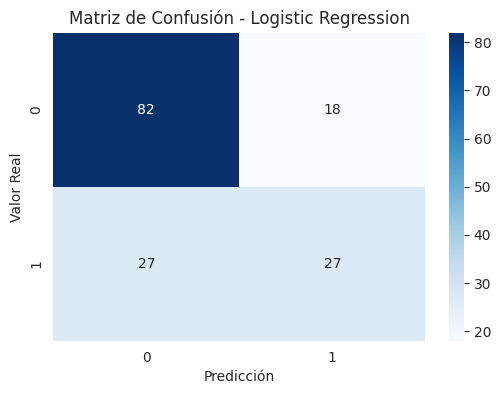

In [11]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [12]:
#Reporte de clasificacion
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



##Random Forest


In [14]:
#Entrenamiento del modelo

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
# Predicciones

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [16]:
# Métricas

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

Accuracy: 0.7792
Precision: 0.7273
Recall: 0.5926
F1-Score: 0.6531
ROC-AUC: 0.8192


In [17]:
# Reporte de Clasificación

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



## XGBOOST


In [21]:
#Modelo
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
#Predicciones
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [23]:
#Métricas
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

Accuracy: 0.7597
Precision: 0.6735
Recall: 0.6111
F1-Score: 0.6408
ROC-AUC: 0.8081


In [24]:
#Reporte de clasificacion
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



##CatBoost

In [28]:
#Entrenamiento del modelo
cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [29]:
#Predicciones
y_pred_cat = cat.predict(X_test)
y_prob_cat = cat.predict_proba(X_test)[:, 1]

In [30]:
#Metricas
print("Accuracy:", round(accuracy_score(y_test, y_pred_cat), 4))
print("Precision:", round(precision_score(y_test, y_pred_cat), 4))
print("Recall:", round(recall_score(y_test, y_pred_cat), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_cat), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_cat), 4))

Accuracy: 0.7403
Precision: 0.64
Recall: 0.5926
F1-Score: 0.6154
ROC-AUC: 0.8224


In [31]:
print(classification_report(y_test, y_pred_cat))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       100
           1       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



##Comparación de modelos

In [32]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "Accuracy": [
        0.7078,
        0.7792,
        0.7597,
        0.7403
    ],
    "Precision": [
        0.6000,
        0.7273,
        0.6735,
        0.6400
    ],
    "Recall": [
        0.5000,
        0.5926,
        0.6111,
        0.5926
    ],
    "F1-Score": [
        0.5455,
        0.6531,
        0.6408,
        0.6154
    ],
    "ROC-AUC": [
        0.8130,
        0.8192,
        0.8081,
        0.8224
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
1,Random Forest,0.7792,0.7273,0.5926,0.6531,0.8192
2,XGBoost,0.7597,0.6735,0.6111,0.6408,0.8081
3,CatBoost,0.7403,0.6400,0.5926,0.6154,0.8224


In [33]:
# Exportacíon de las metricas evaluadas
results.to_csv("metrics.csv", index=False)

## Selección e interpretación del mejor modelo

A partir de la comparación de métricas, Random Forest fue seleccionado como modelo final debido a que presentó el mejor desempeño global, obteniendo los mayores valores de Accuracy, Precision y F1-Score, además de un ROC-AUC competitivo respecto a los demás algoritmos evaluados.

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Glucose,0.274086
5,BMI,0.161903
6,DiabetesPedigreeFunction,0.125020
7,Age,0.112985
4,Insulin,0.091224
2,BloodPressure,0.083518
0,Pregnancies,0.080795
3,SkinThickness,0.070468


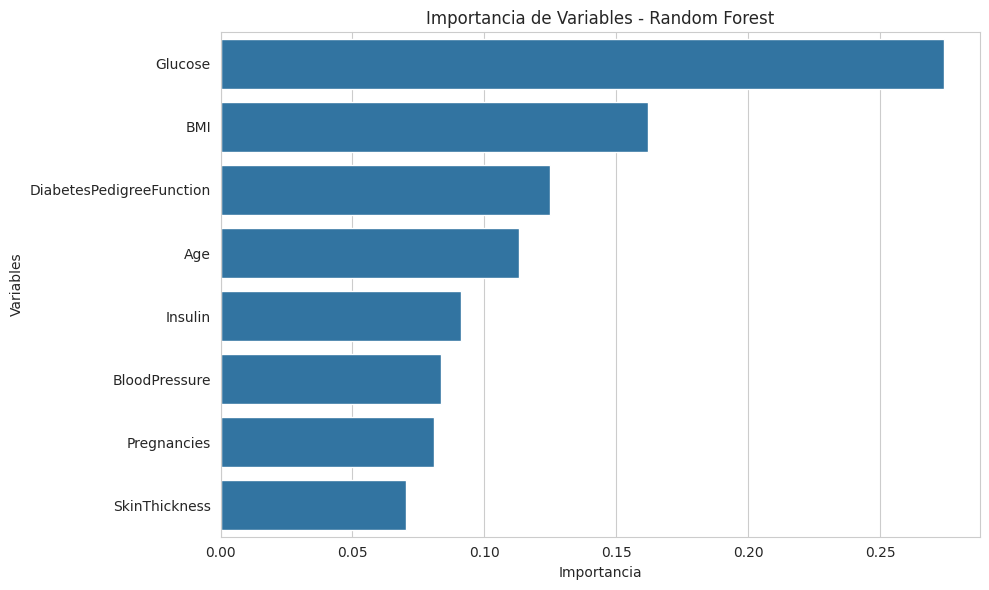

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El análisis de importancia de variables mostró que la concentración de glucosa fue el predictor más relevante para la clasificación de pacientes con diabetes, representando aproximadamente el 27% de la importancia total del modelo. El índice de masa corporal (BMI), la función de riesgo hereditario de diabetes (DiabetesPedigreeFunction) y la edad también mostraron una contribución importante. Estos hallazgos son consistentes con factores de riesgo ampliamente descritos en la literatura médica para el desarrollo de diabetes tipo 2.

In [37]:
#Exportación del mejor modelo
import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(rf, file)

In [36]:
#Exportación del csv
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

## Conclusiones

- Se desarrollaron y compararon cuatro modelos de Machine Learning para la predicción de diabetes tipo 2.

- Random Forest presentó el mejor desempeño global, alcanzando una Accuracy de 0.7792 y un ROC-AUC de 0.8192.

- La concentración de glucosa fue identificada como la variable más importante para la clasificación de pacientes con diabetes.

- El índice de masa corporal (BMI), la edad y la función de riesgo hereditario de diabetes también mostraron una contribución relevante en el modelo.

- Los resultados obtenidos demuestran el potencial de los algoritmos de Machine Learning como herramientas de apoyo para la identificación temprana del riesgo de diabetes.